In [1]:
#import statements
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import matplotlib.pyplot as plt
from torchinfo import summary
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, r2_score
from sklearn.preprocessing import label_binarize
from pathlib import Path
from scipy import signal

In [2]:
def filter_eeg_signal(data, sampling_rate=256, highpass_freq=0.5, notch_freq=60, lowpass_freq=40):
    data = np.asarray(data, dtype=np.float32)
    original_shape = data.shape
    
    # Flatten if 2D to process each channel separately
    if data.ndim == 2:
        n_channels, n_samples = data.shape
        data = data.reshape(n_channels, n_samples)
        is_2d = True
    else:
        data = data.ravel()
        is_2d = False
        n_channels = 1
        n_samples = len(data)
    
    # Initialize filtered data
    filtered_data = np.zeros_like(data)
    
    # Process each channel
    for ch in range(n_channels):
        channel_data = data[ch] if is_2d else data
        
        # 1. High-pass filter at 0.5 Hz
        # Use butterworth filter, 4th order
        nyquist = sampling_rate / 2.0
        highpass_normalized = highpass_freq / nyquist
        if highpass_normalized >= 1.0:
            # If cutoff is too high, skip high-pass filter
            hp_filtered = channel_data
        else:
            b, a = signal.butter(4, highpass_normalized, btype='high')
            hp_filtered = signal.filtfilt(b, a, channel_data)
        
        # 2. Notch filter at 60 Hz (remove power line noise)
        # Quality factor determines bandwidth (higher Q = narrower notch)
        Q = 30.0  # Quality factor for notch filter
        b, a = signal.iirnotch(notch_freq, Q, sampling_rate)
        notch_filtered = signal.filtfilt(b, a, hp_filtered)
        
        # 3. Low-pass filter at 40 Hz
        lowpass_normalized = lowpass_freq / nyquist
        if lowpass_normalized >= 1.0:
            # If cutoff is too high, skip low-pass filter
            lp_filtered = notch_filtered
        else:
            b, a = signal.butter(4, lowpass_normalized, btype='low')
            lp_filtered = signal.filtfilt(b, a, notch_filtered)
        
        # Store filtered channel
        if is_2d:
            filtered_data[ch] = lp_filtered
        else:
            filtered_data = lp_filtered
    
    return filtered_data.reshape(original_shape)


In [3]:
def filter_eeg_dataframe(df, sampling_rate=256, highpass_freq=0.5, notch_freq=60, lowpass_freq=40):
    df = df.copy()
    
    # Apply filter to each segment
    filtered_segments = []
    for segment in df['segment'].values:
        filtered_seg = filter_eeg_signal(
            segment, 
            sampling_rate=sampling_rate,
            highpass_freq=highpass_freq,
            notch_freq=notch_freq,
            lowpass_freq=lowpass_freq
        )
        filtered_segments.append(filtered_seg)
    
    df['segment'] = filtered_segments
    return df

In [4]:
# Run bandpass filters
INPUT_DIR = Path("model_data/orig_eeg_raw")
OUTPUT_DIR = Path("model_data/filtered_glob_ref")

for parquet_path in INPUT_DIR.glob("*.parquet"):
    subject_id = parquet_path.stem
    print(f"Processing subject {subject_id}")

    df = pd.read_parquet(parquet_path)
    df_ref = filter_eeg_dataframe(df)

    output_path = OUTPUT_DIR / parquet_path.name
    df_ref.to_parquet(output_path, index=False)

Processing subject 658631126
Processing subject 743433124
Processing subject 448828559
Processing subject 808176287
Processing subject 948434759
Processing subject 388428916
Processing subject 243057855
Processing subject 405079169
Processing subject 383411591
Processing subject 589945824
Processing subject 66945710
Processing subject 936379109
Processing subject 664708127
Processing subject 276493243
Processing subject 455862105
Processing subject 711784129
Processing subject 719068207
Processing subject 529085459
Processing subject 166402351
Processing subject 79248690
Processing subject 531955818
Processing subject 322849813
Processing subject 644505798
Processing subject 934974129
Processing subject 712150413
Processing subject 236059469
Processing subject 190695762
Processing subject 71375084
Processing subject 472704015
Processing subject 977301626
Processing subject 490856819
Processing subject 122619174
Processing subject 580694521
Processing subject 948253287
Processing subjec

In [74]:
def global_reference_subject(df):
    df = df.copy()
    segments = []
    n_rows = len(df)

    for i in range(0, n_rows, 8):
        block = df.iloc[i:i + 8]

        # Stack segment vectors -> (8, 2560)
        data = np.stack(block["segment"].values)

        # Mean across channels at each time point
        mean_signal = data.mean(axis=0)

        # Subtract mean
        data_ref = data - mean_signal

        # Assign back
        block = block.copy()
        block["segment"] = list(data_ref)
        segments.append(block)

    return pd.concat(segments, ignore_index=True)

In [44]:
"""
# Process all parquet files
INPUT_DIR = Path("model_data/filtered_eeg")
OUTPUT_DIR = Path("model_data/z_score_eeg")

for parquet_path in INPUT_DIR.glob("*.parquet"):
    subject_id = parquet_path.stem
    print(f"Processing subject {subject_id}")

    df = pd.read_parquet(parquet_path)
    df_ref = z_score_subject(df)

    output_path = OUTPUT_DIR / parquet_path.name
    df_ref.to_parquet(output_path, index=False)
"""

'\n# Process all parquet files\nINPUT_DIR = Path("model_data/filtered_eeg")\nOUTPUT_DIR = Path("model_data/z_score_eeg")\n\nfor parquet_path in INPUT_DIR.glob("*.parquet"):\n    subject_id = parquet_path.stem\n    print(f"Processing subject {subject_id}")\n\n    df = pd.read_parquet(parquet_path)\n    df_ref = z_score_subject(df)\n\n    output_path = OUTPUT_DIR / parquet_path.name\n    df_ref.to_parquet(output_path, index=False)\n'

In [3]:
pca_vals = pd.read_parquet('model_data/matched_pca_vectors.parquet')

In [4]:
class CustomDataLoader(Dataset):
    def __init__(self, eeg_dir, pca_vals, n_pca=10, n_segments=1, dtype=torch.float32, 
                 normalize_targets=True, target_mean=None, target_std=None):
        self.eeg_dir = Path(eeg_dir)
        self.n_pca = n_pca
        self.n_segments = n_segments
        self.dtype = dtype
        self.normalize_targets = normalize_targets

        # subject -> PCA target
        self.subject_to_pca = {}
        all_vectors = []
        for _, row in pca_vals.iterrows():
            subj = str(row['subject'])
            vec = np.asarray(row['vector'], dtype=np.float32)
            if vec.shape[0] >= n_pca:
                vec_slice = vec[:n_pca]
                self.subject_to_pca[subj] = vec_slice
                all_vectors.append(vec_slice)

        # Compute robust target normalization statistics (median/IQR)
        # Use median/IQR to reduce impact of extreme outliers (skew=3.14, max=14σ)
        if normalize_targets and len(all_vectors) > 0:
            all_vectors = np.array(all_vectors)
            if target_mean is None:
                self.target_mean = np.median(all_vectors, axis=0, keepdims=True)
                q75 = np.percentile(all_vectors, 75, axis=0, keepdims=True)
                q25 = np.percentile(all_vectors, 25, axis=0, keepdims=True)
                iqr = q75 - q25
                # Scale by IQR/1.35 ≈ std for normal distribution
                self.target_std = (iqr / 1.35) + 1e-8
            else:
                self.target_mean = target_mean
                self.target_std = target_std
        else:
            self.target_mean = None
            self.target_std = None

        # subjects that have EEG parquet
        self.subjects = [
            subj for subj in self.subject_to_pca
            if (self.eeg_dir / f"{subj}.parquet").exists() ]

    def __len__(self):
        return len(self.subjects)
    
    def _fix_len(self, x: np.ndarray) -> np.ndarray:
        """Crop or zero-pad 1D array to self.segment_len."""
        x = np.asarray(x, dtype=np.float32).ravel()
        L = x.shape[0]
        if L == 2560:
            return x
        if L > 2560:
            return x[:2560]
        # pad
        out = np.zeros(2560, dtype=np.float32)
        out[:L] = x
        return out
    
    def __getitem__(self, idx):
        subject_id = self.subjects[idx]
        # target
        y = np.asarray(self.subject_to_pca[subject_id], dtype=np.float32)
        
        # Normalize targets if enabled
        if self.normalize_targets and self.target_mean is not None:
            y = (y - self.target_mean.flatten()) / self.target_std.flatten()
            # Clip extreme outliers to ±5 after normalization
            y = np.clip(y, -5.0, 5.0)
        
        y = torch.tensor(y, dtype=self.dtype)
        # EEG
        df = pd.read_parquet(self.eeg_dir / f"{subject_id}.parquet")

        # --- Select the first n_segments that actually exist (segment_index may start at 176, etc.)
        seg_ids = np.sort(df['segment_index'].unique())
        chosen = seg_ids[: self.n_segments]
        df = df[df['segment_index'].isin(chosen)]

        # channel order from the first chosen segment
        first_seg = chosen[0]
        first_block = df[df['segment_index'] == first_seg]
        channels = first_block['channel_name'].astype(str).tolist()[:8]

        per_channel = []
        for ch in channels:
            ch_df = df[df['channel_name'].astype(str) == ch].sort_values('segment_index')
            ch_df = ch_df.iloc[: self.n_segments]
            
            segs = [self._fix_len(v) for v in ch_df['segment'].values]
            concat = np.concatenate(segs)
            # Ensure consistent size by tiling if fewer segments available
            expected_len = 2560 * self.n_segments
            if len(concat) < expected_len:
                repeats = int(np.ceil(expected_len / len(concat)))
                concat = np.tile(concat, repeats)[:expected_len]
            per_channel.append(concat)

        X = np.stack(per_channel)  # (8, 2560*n_segments)
        
        # Per-subject z-score normalization of EEG inputs
        # Standardize each subject's EEG to mean=0, std=1 across all channels and time
        x_mean = X.mean()
        x_std = X.std() + 1e-8  # avoid division by zero
        X = (X - x_mean) / x_std
        
        X = torch.tensor(X, dtype=self.dtype)
        return X, y

In [5]:
# CRITICAL FIX: Ensure n_pca matches between dataset and model
# Also consider using more segments for richer features
# IMPORTANT: normalize_targets=True normalizes PCA targets to help training
dataset = CustomDataLoader(
    eeg_dir="model_data/filtered_glob_ref",
    pca_vals=pca_vals,
    n_pca=1,  # Make sure this matches the model's n_outputs
    n_segments=5,
    normalize_targets=True,
)

In [6]:
# Stratified split: preserve target distribution in train/test (bin first PCA component into quartiles)
train_frac = 0.8
targets = np.array([dataset.subject_to_pca[dataset.subjects[i]][0] for i in range(len(dataset))])
bins = np.percentile(targets, [25, 50, 75])
strata = np.digitize(targets, bins)
indices = np.arange(len(dataset))
train_idx, test_idx = train_test_split(indices, train_size=train_frac, stratify=strata, random_state=42)
train_ds = Subset(dataset, train_idx.tolist())
test_ds = Subset(dataset, test_idx.tolist())

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

In [7]:
X, y = next(iter(train_loader))
print(X.shape)  # (B, 8, 2560 * n_segments)
print(y.shape)  # (B, n_pca)

torch.Size([32, 8, 12800])
torch.Size([32, 1])


In [8]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)

        # projection shortcut if shape changes
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out, inplace=True)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out

In [9]:
class ResNet1D(nn.Module):
    def __init__(self, in_channels=8, n_outputs=10, base_channels=32, blocks_per_stage=(2, 2, 2), kernel_size=3, dropout=0.2):
        super().__init__()
        self.in_ch = base_channels
        
        # Increased model capacity: more channels and more stages
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=kernel_size, stride=2,
                      padding=kernel_size // 2, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
        )

        # 3 stages with more blocks for better feature extraction
        self.stage1 = self._make_stage(base_channels, blocks_per_stage[0], stride=1, kernel_size=kernel_size)
        self.stage2 = self._make_stage(base_channels * 2, blocks_per_stage[1], stride=2, kernel_size=kernel_size)
        self.stage3 = self._make_stage(base_channels * 4, blocks_per_stage[2], stride=2, kernel_size=kernel_size)

        # Final layers with dropout
        self.head_bn = nn.BatchNorm1d(base_channels * 4)
        self.head_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(base_channels * 4, n_outputs)

    def _make_stage(self, out_ch, n_blocks, stride, kernel_size):
        blocks = []
        blocks.append(ResBlock1D(self.in_ch, out_ch, kernel_size=kernel_size, stride=stride))
        self.in_ch = out_ch
        for _ in range(1, n_blocks):
            blocks.append(ResBlock1D(self.in_ch, out_ch, kernel_size=kernel_size, stride=1))
        return nn.Sequential(*blocks)

    def forward(self, x):
        # x: (B, 8, L)
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)

        # Global average pool over time dimension
        x = x.mean(dim=-1)   # (B, C)

        x = self.head_bn(x)
        x = self.head_dropout(x)
        out = self.fc(x)     # (B, n_outputs)
        return out

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.backends.mps.is_available() else device)

In [11]:
torch.manual_seed(0)

n_pca = 1
cnn = ResNet1D(
    in_channels=8, 
    n_outputs=n_pca, 
    base_channels=32,
    blocks_per_stage=(2, 2, 2),
    kernel_size=3,
    dropout=0.3
).to(device)

total_epochs = 0

In [12]:
summary(cnn)

Layer (type:depth-idx)                   Param #
ResNet1D                                 --
├─Sequential: 1-1                        --
│    └─Conv1d: 2-1                       768
│    └─BatchNorm1d: 2-2                  64
│    └─ReLU: 2-3                         --
├─Sequential: 1-2                        --
│    └─ResBlock1D: 2-4                   --
│    │    └─Conv1d: 3-1                  3,072
│    │    └─BatchNorm1d: 3-2             64
│    │    └─Conv1d: 3-3                  3,072
│    │    └─BatchNorm1d: 3-4             64
│    │    └─Identity: 3-5                --
│    └─ResBlock1D: 2-5                   --
│    │    └─Conv1d: 3-6                  3,072
│    │    └─BatchNorm1d: 3-7             64
│    │    └─Conv1d: 3-8                  3,072
│    │    └─BatchNorm1d: 3-9             64
│    │    └─Identity: 3-10               --
├─Sequential: 1-3                        --
│    └─ResBlock1D: 2-6                   --
│    │    └─Conv1d: 3-11                 6,144
│    │    └

In [13]:
def compute_test_r2(model, device, dataloader, dataset):
    """Compute R² on test set. Denormalizes if dataset uses target normalization."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for inputs, tgt in dataloader:
            inputs = inputs.to(device)
            out = model(inputs)
            preds.append(out.cpu().numpy())
            targets.append(tgt.numpy())
    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    if hasattr(dataset, 'normalize_targets') and dataset.normalize_targets and dataset.target_mean is not None:
        preds = preds * dataset.target_std.flatten() + dataset.target_mean.flatten()
        targets = targets * dataset.target_std.flatten() + dataset.target_mean.flatten()
    return r2_score(targets.flatten(), preds.flatten())

In [14]:
# Basic training: constant LR, no weight decay, no scheduler. Fine-tune after validation loss reduces.
lr = 1e-3
optim = torch.optim.AdamW(cnn.parameters(), lr=lr)

In [15]:
loss_fn = nn.MSELoss()

In [16]:
# cnn.load_state_dict(torch.load("models/resnet1d_model.pt"))
# cnn.eval()

# optim.load_state_dict(torch.load("models/resnet1d_optim.pt"))

In [17]:
def train_epoch(model, device, dataloader, loss_fn, optimizer):
    model.train()
    train_loss = 0.0

    for inputs, targets in dataloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        loss = loss_fn(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    return train_loss / len(dataloader)

In [18]:
def test_epoch(model, device, dataloader, loss_fn):
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)

            val_loss += loss.item()

    return val_loss / len(dataloader)

In [19]:
tloss_vals = []
vloss_vals = []
r2_vals = []
best_test_loss = float('inf')
num_epochs = 50

In [96]:
for epoch in range(num_epochs):
    total_epochs += 1

    train_loss = train_epoch(cnn, device, train_loader, loss_fn, optim)
    test_loss = test_epoch(cnn, device, test_loader, loss_fn)
    tloss_vals.append(train_loss)
    vloss_vals.append(test_loss)
    
    # R² on test set (uses underlying dataset for denormalization)
    r2 = compute_test_r2(cnn, device, test_loader, dataset)
    r2_vals.append(r2)
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(cnn.state_dict(),'model_data/models/resnet1d_model_v9_best.pt')
        torch.save(optim.state_dict(), "model_data/models/resnet1d_optim_v9_best.pt")
    
    if epoch == num_epochs - 1:
        torch.save(cnn.state_dict(), 'model_data/models/resnet1d_model_v9_last.pt')
        torch.save(optim.state_dict(), "model_data/models/resnet1d_optim_v9_last.pt")
    
    print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f} \t R² {:.4f} \t lr {:.6f}'.format(
        epoch + 1, num_epochs, train_loss, test_loss, r2, optim.param_groups[0]['lr']))


 EPOCH 1/50 	 train loss 1.683 	 val loss 1.356 	 R² -0.0512 	 lr 0.001000

 EPOCH 2/50 	 train loss 1.544 	 val loss 1.281 	 R² 0.0085 	 lr 0.001000

 EPOCH 3/50 	 train loss 1.518 	 val loss 1.125 	 R² 0.1288 	 lr 0.001000

 EPOCH 4/50 	 train loss 1.468 	 val loss 1.185 	 R² 0.0820 	 lr 0.001000

 EPOCH 5/50 	 train loss 1.452 	 val loss 1.374 	 R² -0.0639 	 lr 0.001000

 EPOCH 6/50 	 train loss 1.381 	 val loss 1.160 	 R² 0.1021 	 lr 0.001000

 EPOCH 7/50 	 train loss 1.369 	 val loss 1.260 	 R² 0.0248 	 lr 0.001000

 EPOCH 8/50 	 train loss 1.371 	 val loss 1.163 	 R² 0.0999 	 lr 0.001000

 EPOCH 9/50 	 train loss 1.309 	 val loss 1.202 	 R² 0.0689 	 lr 0.001000

 EPOCH 10/50 	 train loss 1.292 	 val loss 2.005 	 R² -0.5515 	 lr 0.001000

 EPOCH 11/50 	 train loss 1.303 	 val loss 1.797 	 R² -0.3902 	 lr 0.001000

 EPOCH 12/50 	 train loss 1.327 	 val loss 1.300 	 R² -0.0049 	 lr 0.001000

 EPOCH 13/50 	 train loss 1.268 	 val loss 1.237 	 R² 0.0432 	 lr 0.001000

 EPOCH 14/50 	 

In [1]:
epochs = list(range(1, len(tloss_vals) + 1))

NameError: name 'tloss_vals' is not defined

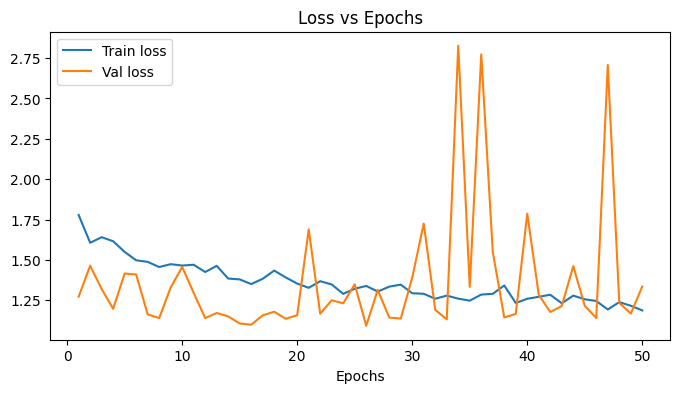

In [64]:
plt.figure(figsize=(8, 4))
plt.plot(epochs, tloss_vals, label='Train loss')
plt.plot(epochs, vloss_vals, label='Val loss')
plt.xlabel('Epochs')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()

In [65]:
def moving_avg(array, window_len=5):
    avg_loss = np.zeros(len(array) - window_len)
    for i in range(avg_loss.size):
        avg_loss[i] = np.mean(array[i:i+window_len])
    return avg_loss

In [66]:
vloss_avg = moving_avg(vloss_vals, window_len=10)

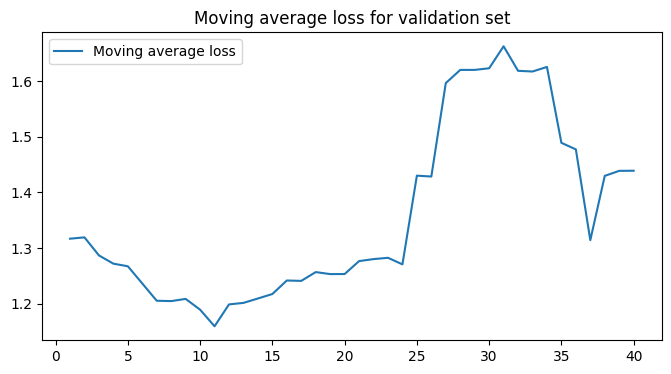

In [67]:
plt.figure(figsize=(8, 4))
plt.plot(list(range(1, len(vloss_avg)+1)), vloss_avg, label='Moving average loss')
plt.title('Moving average loss for validation set')
plt.legend()
plt.show()

In [24]:
cnn.load_state_dict(torch.load('model_data/models/resnet1d_model_v9_best.pt'))

<All keys matched successfully>

In [25]:
cnn.eval()
with torch.no_grad():
    X, y_true = next(iter(test_loader))
    X = X.to(device)
    y_true = y_true.to(device)
    y_pred = cnn(X)

In [26]:
y_true_np = y_true.detach().cpu().numpy()
y_pred_np = y_pred.detach().cpu().numpy()

print("Batch shapes:", X.shape, y_true_np.shape, y_pred_np.shape)

Batch shapes: torch.Size([32, 8, 12800]) (32, 1) (32, 1)


In [29]:
#Calculate R-squared on the entire test dataset
cnn.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        outputs = cnn(inputs)
        
        # Store predictions and targets
        all_predictions.append(outputs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

In [30]:
# Concatenate all batches (run the prediction cell above first if empty)
if not all_predictions:
    raise RuntimeError("all_predictions is empty. Run the cell above to collect predictions from test_loader first.")
all_predictions = np.concatenate([np.atleast_2d(p) for p in all_predictions], axis=0)
all_targets = np.concatenate([np.atleast_2d(t) for t in all_targets], axis=0)

# IMPORTANT: If targets were normalized, denormalize predictions for evaluation
# Check if dataset has normalization parameters
if hasattr(dataset, 'normalize_targets') and dataset.normalize_targets and dataset.target_mean is not None:
    # Denormalize predictions
    all_predictions_denorm = all_predictions * dataset.target_std.flatten() + dataset.target_mean.flatten()
    all_targets_denorm = all_targets * dataset.target_std.flatten() + dataset.target_mean.flatten()
    print("Note: Using denormalized values for R² calculation")
    print(f"Target mean: {dataset.target_mean.flatten()}, std: {dataset.target_std.flatten()}")
else:
    all_predictions_denorm = all_predictions
    all_targets_denorm = all_targets

# Calculate R-squared
# If n_pca > 1, calculate R² for each output dimension
if all_predictions_denorm.shape[1] > 1:
    r2_scores = []
    for i in range(all_predictions_denorm.shape[1]):
        r2 = r2_score(all_targets_denorm[:, i], all_predictions_denorm[:, i])
        r2_scores.append(r2)
        print(f"R² score for output dimension {i}: {r2:.4f}")
    print(f"\nMean R² score across all dimensions: {np.mean(r2_scores):.4f}")
else:
    # Single output dimension
    r2 = r2_score(all_targets_denorm.flatten(), all_predictions_denorm.flatten())
    print(f"R² score on dataset: {r2:.4f}")
    
    # Additional diagnostics
    mse = np.mean((all_targets_denorm.flatten() - all_predictions_denorm.flatten()) ** 2)
    mae = np.mean(np.abs(all_targets_denorm.flatten() - all_predictions_denorm.flatten()))
    print(f"MSE: {mse:.4f}, MAE: {mae:.4f}")
    print(f"Target range: [{all_targets_denorm.min():.2f}, {all_targets_denorm.max():.2f}]")
    print(f"Prediction range: [{all_predictions_denorm.min():.2f}, {all_predictions_denorm.max():.2f}]")

Note: Using denormalized values for R² calculation
Target mean: [-0.3551612], std: [1.06611859]
R² score on dataset: 0.4338
MSE: 0.9831, MAE: 0.7238
Target range: [-4.51, 4.98]
Prediction range: [-2.82, 2.27]


In [29]:
# Additional evaluation metrics
correlation = np.corrcoef(all_targets_denorm.flatten(), all_predictions_denorm.flatten())[0, 1]
print(f"Correlation: {correlation:.4f}")
print(f"Prediction std: {all_predictions_denorm.std():.4f}, Target std: {all_targets_denorm.std():.4f}")

Correlation: 0.3816
Prediction std: 0.6030, Target std: 1.1862
